<a href="https://colab.research.google.com/github/oyeyemixisco/animalClassifier/blob/main/FaceRecognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Home Assignment — Session 3
# Face Recognition: Embeddings, Verification & Identification
### Machine Learning I — UPEC | Arezoo Ghodsifard

---

## Instructions

This is a **project-style assignment**. You will extend the face recognition pipeline from the Session 3 practical notebook with new tasks, experiments, and your own analysis.

- Work **individually** — each student submits their own notebook
- Submit **both** your completed `.ipynb` file **and** a PDF export on Teams
- Make sure all cells are **run** before submitting — outputs must be visible in the PDF
- Write your answers to theory questions in the **markdown cells provided**
- **Deadline:** indicated on Teams

---

## Grading Breakdown

| Part | Topic | Points |
|---|---|---|
| **Part 1** | Theory Questions | 25 pts |
| **Part 2** | Coding Tasks | 50 pts |
| **Part 3** | Extension Project | 20 pts |
| **Part 4** | Reflection | 5 pts |
| | **Total** | **100 pts** |

---

## Student Information

**Name:** **OYEYEMI Dare Azeez**  
**Student ID:** **32521235**  
**Date:** **18-03-2025**

---
## Setup — Run This First

This cell installs and imports everything you need. Run it before anything else.

In [54]:
# Install packages (Colab-safe)
!pip install facenet-pytorch --no-deps -q
!pip install umap-learn -q

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_curve, auc,
    adjusted_rand_score
)
from sklearn.preprocessing import normalize
from scipy.spatial.distance import cosine

import torch
import torchvision.transforms as transforms
from facenet_pytorch import InceptionResnetV1

import umap
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")

All libraries imported successfully!
PyTorch version: 2.10.0+cpu


In [55]:
# ── Load dataset and extract embeddings (same as Session 3 notebook) ─────
# Run this cell as-is — it prepares the data you will use throughout the assignment.

print("Loading LFW dataset...")
lfw = fetch_lfw_people(min_faces_per_person=30, resize=0.5, color=True)

SELECTED_PEOPLE = ['George W Bush', 'Colin Powell', 'Tony Blair', 'Vladimir Putin', 'Ariel Sharon']
COLORS = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']

selected_idx = [np.where(lfw.target_names == p)[0][0] for p in SELECTED_PEOPLE]
mask = np.isin(lfw.target, selected_idx)
images = lfw.images[mask]
label_map = {old: new for new, old in enumerate(selected_idx)}
labels = np.array([label_map[l] for l in lfw.target[mask]])

print(f"Dataset ready: {len(images)} images, {len(SELECTED_PEOPLE)} people")

# Load FaceNet and extract embeddings
print("\nLoading FaceNet model...")
facenet = InceptionResnetV1(pretrained='vggface2').eval()

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((160, 160)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

def get_embedding(img_float):
    img_uint8 = (img_float * 255).astype(np.uint8)
    tensor = transform(img_uint8).unsqueeze(0)
    with torch.no_grad():
        embedding = facenet(tensor).squeeze().numpy()
    return embedding

print(f"Extracting embeddings for {len(images)} images... (~2 min)")
t0 = time.time()
embeddings = normalize(np.array([get_embedding(img) for img in images]), norm='l2')
print(f"Done in {time.time()-t0:.0f}s. Shape: {embeddings.shape}")

# Gallery / Query split
X_gallery, X_query, y_gallery, y_query = train_test_split(
    embeddings, labels, test_size=0.2, random_state=42, stratify=labels
)
print(f"\nGallery: {len(X_gallery)} images | Query: {len(X_query)} images")
print("\nSetup complete — you can now start the assignment!")

Loading LFW dataset...
Dataset ready: 1036 images, 5 people

Loading FaceNet model...
Extracting embeddings for 1036 images... (~2 min)
Done in 175s. Shape: (1036, 512)

Gallery: 828 images | Query: 208 images

Setup complete — you can now start the assignment!


---
# Part 1 — Theory Questions
### 25 points (5 points each)

Answer each question in the markdown cell below it. Write in your own words — do not copy from the slides. Aim for 3–6 sentences per answer.

---
### Q1 — Embeddings vs Raw Pixels (5 pts)

In Session 3 we saw that comparing faces using raw pixel values fails, while using FaceNet embeddings works well.

**Explain in your own words:**
1. Why does pixel-by-pixel comparison fail for face recognition?
2. What property of embeddings makes them better for this task?
3. Give one real-world example where this difference matters.

**Your answer:**

**1. Why does pixel-by-pixel comparison fail for face recognition?**

The main reason pixel-by-pixel comparison fails for face recognition is because it relies solely on raw pixel intensity values, which represent only the appearance of an image rather than identity-specific features. Just as we were taught in ImageProcessing course in 1st Semester that even when traditional image processing techniques divide images into small blocks (e.g., 4×4 or 8×8), the comparison still relies on low-level pixel information and does not capture meaningful facial characteristics.

Pixel-by-pixel methods are highly sensitive to variations such as lighting, facial expression, and also include irrelevant information such as background, making them unreliable for accurate face recognition, meaning images of the same person appear very different numerically.

In summary, pixel-by-pixel comparison fail because it do not learn or represent identity, which is the fundamental requirement in face recognition application.

*`*

**2. What property of embeddings makes them better for this task?**
Face recognition requires capturing identity-specific features rather than relying on raw pixel intensity values. This makes embeddings very effective because they capture identity-relevant features in a compact and meaningful representation.


A key property is that embeddings are invariant to variations such as lighting, pose, and facial expression. In the embedding space, images of the same person are mapped close together, while images of different people are far apart. This allows for reliable comparison using distance metrics, making embeddings much more robust than raw pixel values.

*`*

**3. Give one real-world example where this difference matters.**
An example is my use of iPhone face unlock (Face ID). When I try to unlock my phone, my appearance may vary depending on conditions such as being indoors versus outdoors in bright sunlight, slight changes in head position, or different facial expressions. A pixel-based system would likely fail in this scenario because these variations significantly change the raw pixel values of the image.

However, embedding-based systems such as FaceNet can still recognise me because they rely on identity-specific features rather than exact pixel matching. This allows the system to consistently authenticate me despite these variations.

This simple scenario demonstrates how embedding are more robust and reliable than pixel-by-pixel comparison for real-world face recognition tasks where conditions are not controlled.


---
### Q2 — Triplet Loss (5 pts)

The triplet loss formula is:

$$\mathcal{L} = \max\left(0,\ d(A, P) - d(A, N) + \alpha\right)$$

**Explain:**
1. What are A, P, and N in this formula?
2. What does the margin $\alpha$ do — what happens if we set it to 0?
3. When does the loss equal 0? What does that mean geometrically in embedding space?

**Your answer:**

1. What are A, P, and N in this formula?
In the Triplet Loss Formula, the:
  
  - A: means the Anchor and represent the reference image or the person of interest image. Let's think of the `A` as the enrolled image in our database, which is the primary reference used whenever we want to perform identity verification or identification.

  - P: represent the truth image of thesame person will are comparing with in A, which is known as Positive. Meaning A and P are thesame person even if both images have different variation like emotions, pose or background.


  - N: represent image of a different person entirely from the person of interest `A` and it is known as Negative. This image acts as the contrast and it is used to ensure that the model can distinguish between different identities.


2. What does the margin  𝛼  do — what happens if we set it to 0?

    The main function of the margin 𝛼 is to ensure that the different between the `Anchor (A)` and `Negative (N)` is significantly larger than the distance between the `Anchor (A)` and `Positive (P)`, creating a clear 'gap' between the faces.

    If we set margin 𝛼 to 0, there will be no required separation gap between positive and negative pairs. This can lead to weak learning, where the model barely distinguishes between different individual faces, making it less robust and more prone to errors in real-world conditions.

3. When does the loss equal 0? What does that mean geometrically in embedding space?

   The loss equals 0 when the distance between the Anchor (A) and the Negative (N) is greater than the distance between the Anchor (A) and the Positive (P) plus the margin 𝛼, meaning the triplet constraint is satisfied. This means the Negative image is sufficiently far from the Anchor, while the Positive image remains close.


    Geometrically, this means that in the embedding space, the Anchor and Positive are close together, while the Negative is pushed far away from the Anchor by at least the margin. This creates a clear separation between different identities, ensuring that images of the same person form tight clusters, while images of different people are well separated. This created a clear visual boundary between "This is Me" and "This is Not Me."

---
### Q3 — Verification vs Identification vs Clustering (5 pts)

**Fill in this table** and then write 2–3 sentences explaining the key difference between verification and identification:

| | Verification | Identification | Clustering |
|---|---|---|---|
| Question it answers |Is this person who they claim to be?|Who is this person?|Which images belong to thesame person?|
| Input |Query image and the claimed identity| Image only|Collection of photos|
| Output | Yes or No response| Person’s identity (name/ID)| Groups of similar faces|
| Needs labels? | Yes|Yes |No label |
| Real-world example |  Bank Vault Face ID| Biometric Attendance System| Snapchat Photos Grouping|

**Your answer (table + explanation):**

The main difference between verification and identification is that verification is a one-to-one (1:1) comparison, where the system checks if a person matches a claimed identity. In contrast, identification is a one-to-many (1:N) comparison, where the system searches a database to determine who the person is, just as the question both answered is filled in the table. As a result, identification is generally more complex and computationally intensive than verification.

Clustering on otherhand is an unsupervised task, meaning the system groups images based on similarity without any prior identity labels, automatically discovering which faces belong to the same person.


**Simple summary**

**Verification (1:1)** means: (Query Image) --> Compare with --> (Claimed Identity) then Output = Either Yes / No

**Identification (1:N)** means:

(Query Image) --> Compare with:
- Person A
- Person B
- Person C

Output: Best Match out of the comparisons = Identity

**Clustering** means (Unsupervised)

   - (Image1)    - (Image2)   - (Image3)   - (Image4)
       
       then
          -> Group them by similarity

    Output:
      Group 1 = images of same person
      Group 2 = images of another same person

---
### Q4 — Gallery and Query Split (5 pts)

In the Session 3 notebook we split our data into a **Gallery** and a **Query** set instead of the usual "train" and "test".

**Answer:**
1. Why do we need this split even though we are not training any model?
2. Which tasks use the Gallery? Which use only the Query? Which use all data?
3. What would go wrong if we used the same images in both Gallery and Query for identification?

**Your answer:**
1. Why do we need this split even though we are not training any model?

   The Gallery and Query sets serve a similar purpose to the traditional train/test split, but in this case, we are performing matching rather than learning. Even though we are no training any model, we still need to evaluate the system’s recognition performance.

   The Gallery represents the stored database of known identities, while the Query represents new, unseen images that need to be matched against this database. This separation allows us to simulate real world comparison scenario, where a new input image is compared against existing records.

2. Which tasks use the Gallery? Which use only the Query? Which use all data?

  - Verification and Identification both use the Gallery and Query sets:

    - Verification compares a query image against a specific enrolled (registered) identity in the Gallery (database) (1:1).

    - Identification compares a query image against all identities in the Gallery (1:N).


  - Clustering uses all data (no split required), since it groups images based on similarity without predefined labels.

  - The Query set alone represents the input images to be tested, but meaningful comparison always involves the Gallery.


  3. What would go wrong if we used the same images in both Gallery and Query for identification?

  If the same images are in both sets, the system would simply match each query image to its exact identical copy in the Gallery. This results in perfect but false accuracy that doesn't reflect real-world performance.

  In a real scenario, a person’s face changes slightly due to lighting, angle, or expression. Testing with identical images doesn't prove the system understands identity but it only proves it can identify a specific file. This creates a biased evaluation because the model isn't being challenged to generalize across different photos of the same human being.
  
  

---
### Q5 — CNN Recap from Session 2 (5 pts)

FaceNet uses a deep CNN (InceptionResnetV1) as its backbone.

**Answer:**
1. What is the role of convolutional layers in this network — what do they detect?
2. Why do we remove the final classification layer of FaceNet when extracting embeddings?
3. FaceNet outputs a 512-dimensional vector. What would happen to face recognition performance if we used only 2 dimensions instead? What if we used 10,000?

**Your answer:**

1. What is the role of convolutional layers in this network — what do they detect?

    The role of convolutional layers in the network is to automatically learn and extract hierarchical features from face images. Early layers detect low-level features such as edges, textures, and simple patterns, while deeper layers capture more complex and abstract features such as facial components (eyes, nose, mouth) and their spatial relationships.

    The convoluntional layers learn identity-relevant features that are useful for distinguishing between different individuals.


2. Why do we remove the final classification layer of FaceNet when extracting embeddings?

    The final classification layer is use to predict specific identities seen during training, which makes it task-specific and limited to known classes. For the face recognition, we are not interested in class labels but in a general representation of faces. By removing this layer, we get the embeddings that capture identity features in a way that can be used to compare any faces, including unseen individuals. This allows FaceNet to generalise beyond the training dataset.

3. FaceNet outputs a 512-dimensional vector. What would happen to face recognition performance if we used only 2 dimensions instead? What if we used 10,000?

  - If we used only 2 dimensions, the embedding space would be very small to capture the complexity of facial features. Many different faces would overlap in this limited space, leading to poor separation between identities and reduced recognition accuracy.

- If we decide to use 10,000 dimensions, the embedding would become excessively large, introducing redundancy and noise. This can make the model less efficient, harder to generalise, and more prone to overfitting, without necessarily improving performance.

---
# Part 2 — Coding Tasks
### 50 points

Complete each task by filling in the `# TODO` sections. Do not change any code outside the TODO blocks unless instructed. Each task has a point value and hints.

---
### Task 1 — Threshold Experiment (10 pts)

In Session 3 we used a fixed threshold of `0.50` for face verification. But is that the best value?

Your task: **test 10 different threshold values** and find the one that gives the highest verification accuracy on the Query set. Plot accuracy vs threshold.

Built 715 verification pairs
Best threshold: 0.60  →  Accuracy: 100.00%


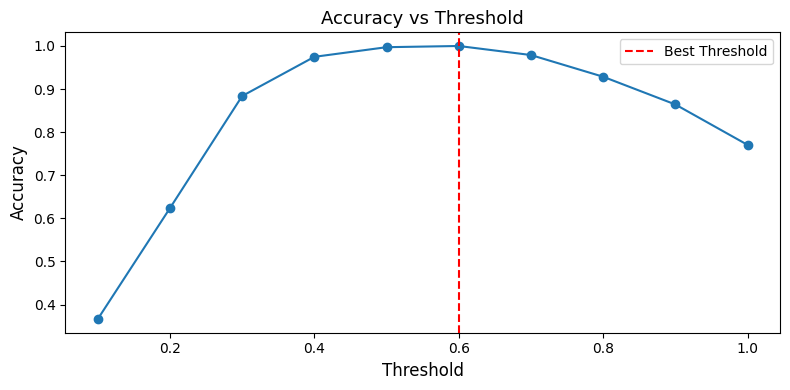

In [56]:
# ── Task 1: Find the best verification threshold ──────────────────────────

# Step 1: Build verification pairs from the Query set
# (same approach as Session 3 notebook)
np.random.seed(42)
pair_emb1, pair_emb2, pair_labels = [], [], []

for label in range(5):
    idx       = np.where(y_query == label)[0]
    other_idx = np.where(y_query != label)[0]
    for i in range(min(len(idx), 15)):
        for j in range(i+1, min(len(idx), 15)):
            pair_emb1.append(X_query[idx[i]])
            pair_emb2.append(X_query[idx[j]])
            pair_labels.append(1)
    chosen_other = np.random.choice(other_idx, min(len(other_idx), 50), replace=False)
    for i in range(min(len(idx), 5)):
        for j in range(min(len(chosen_other), 10)):
            pair_emb1.append(X_query[idx[i]])
            pair_emb2.append(X_query[chosen_other[j]])
            pair_labels.append(0)

# Pre-compute all pairwise distances
distances = [cosine(e1, e2) for e1, e2 in zip(pair_emb1, pair_emb2)]
print(f"Built {len(distances)} verification pairs")

# Step 2: Test 10 threshold values between 0.1 and 1.0
# TODO: define a list of 10 threshold values to test
# Hint: use np.linspace(0.1, 1.0, 10)
thresholds = np.linspace(0.1, 1.0, 10)

# TODO: for each threshold, compute accuracy and store it
# Hint: a prediction is 1 (same person) if distance < threshold, else 0
accuracies = []  # <- fill this list
for t in thresholds:
    preds = [1 if d < t else 0 for d in distances]
    acc   = np.mean(np.array(preds) == np.array(pair_labels))
    accuracies.append(acc)

# Step 3: Find and print the best threshold
# TODO: find the threshold with the highest accuracy
best_idx = np.argmax(accuracies)
best_threshold = thresholds[best_idx]
best_accuracy = accuracies[best_idx]

print(f"Best threshold: {best_threshold:.2f}  →  Accuracy: {best_accuracy:.2%}")

# Step 4: Plot accuracy vs threshold
# TODO: create a line plot with threshold on x-axis and accuracy on y-axis
# Mark the best threshold with a vertical dashed line

fig, ax = plt.subplots(figsize=(8, 4))
# <- your plotting code here
ax.plot(thresholds, accuracies, marker='o')
ax.axvline(x=best_threshold, linestyle='--', color='red', label='Best Threshold')
ax.legend()
ax.set_xlabel('Threshold', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Accuracy vs Threshold', fontsize=13)
plt.tight_layout()
plt.show()

**Task 1 — Analysis (write 2–3 sentences):**
- What is the best threshold you found?
- Is it the same as the 0.50 used in the session notebook? Why might it differ?
- What happens to accuracy when the threshold is very low (e.g. 0.1) or very high (e.g. 0.9)?


*Answer:*

The best threshold is approximately 0.60, where the verification accuracy reaches its maximum. This is slightly different from the 0.50 used in the session notebook because the optimal threshold always depends on the specific dataset distribution of your embeddings. At a very low threshold like 0.1, the model is too strict and incorrectly rejects true matches, while at a high threshold like 0.9, it becomes too relaxed and begins incorrectly accepting impostors.

---
### Task 2 — Confusion Matrix for Identification (10 pts)

In Session 3 we measured identification accuracy as a single number. A **confusion matrix** shows us exactly which people get confused with each other.

Your task: run KNN identification and plot a labeled confusion matrix.

Identification Accuracy: 100.00%


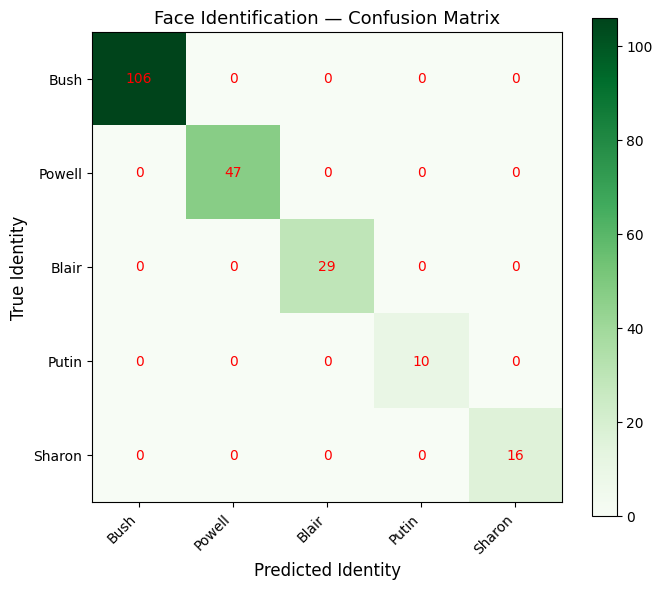

In [57]:
# ── Task 2: Confusion matrix for face identification ─────────────────────

# Step 1: Train KNN on Gallery and predict on Query
# TODO: create a KNeighborsClassifier with n_neighbors=5 and metric='cosine'
knn = KNeighborsClassifier(n_neighbors=5, metric='cosine')  # <- your code here

# TODO: fit on Gallery, predict on Query
# <- your code here
knn.fit(X_gallery, y_gallery)
y_pred = knn.predict(X_query)  # <- your code here

print(f"Identification Accuracy: {accuracy_score(y_query, y_pred):.2%}")

# Step 2: Compute the confusion matrix
# TODO: compute confusion matrix using sklearn's confusion_matrix()
cm = confusion_matrix(y_query, y_pred)  # <- your code here

# Step 3: Plot the confusion matrix as a heatmap
# TODO: plot cm as an image using plt.imshow()
# - Use short last names as tick labels (e.g. 'Bush', 'Powell', etc.)
# - Add the number in each cell using ax.text()
# - Add a colorbar
short_names = [name.split()[-1] for name in SELECTED_PEOPLE]

fig, ax = plt.subplots(figsize=(7, 6))
# <- your plotting code here
im = ax.imshow(cm, cmap='Greens')

# Setting short last names as tick labels
ax.set_xticks(np.arange(len(short_names)))
ax.set_yticks(np.arange(len(short_names)))
ax.set_xticklabels(short_names, rotation=45, ha='right')
ax.set_yticklabels(short_names)

# Adding the numbers inside each cell using ax.text()
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', color='red')

# Adding colorbar
plt.colorbar(im, ax=ax)

ax.set_xlabel('Predicted Identity', fontsize=12)
ax.set_ylabel('True Identity', fontsize=12)
ax.set_title('Face Identification — Confusion Matrix', fontsize=13)
plt.tight_layout()
plt.show()

**Task 2 — Analysis (write 3–4 sentences):**
- Which person is identified most accurately? Which is identified least accurately?
- Are there any pairs of people who get confused with each other? Why might that happen?
- Does the number of images per person (Bush: 530, Putin: 49) affect the results? How?

*Answer*

As seen from the confusion matrix, all individuals are identified perfectly, with Bush having the highest number of correct predictions (106) and Putin the lowest (10), though this difference reflects the number of samples rather than accuracy, as overall accuracy is 100%. There are no confusions between any pairs of people, as shown by the absence of off-diagonal values in the confusion matrix, meaning the learned embeddings are well separated in the feature space. However, this perfect performance may also indicate that the task is relatively easy for the model or that the data distribution between Gallery and Query is very similar, potentially leading to optimistic results.

The number of images per person does affect the model's results, as persons with more samples (e.g Bush) provide more training data for the model to learn the various angles, lighting conditions, and expressions associated with their face, potentially making their representations more robust compared to those with fewer samples (e.g Putin).

---
### Task 3 — K-Means Clustering (15 pts)

In Session 3 we covered clustering as the third face recognition task but did not implement it. Your task: **implement K-Means clustering** on the full embedding space and evaluate how well it recovers the 5 identities.

Clustering is **unsupervised** — K-Means does not see any labels. We use the labels only at the end to evaluate quality.

K-Means found 5 clusters
Cluster sizes: [530 236  77  49 144]

Adjusted Rand Score (ARI): 1.000
(1.0 = perfect clustering, 0.0 = random)

Running UMAP...


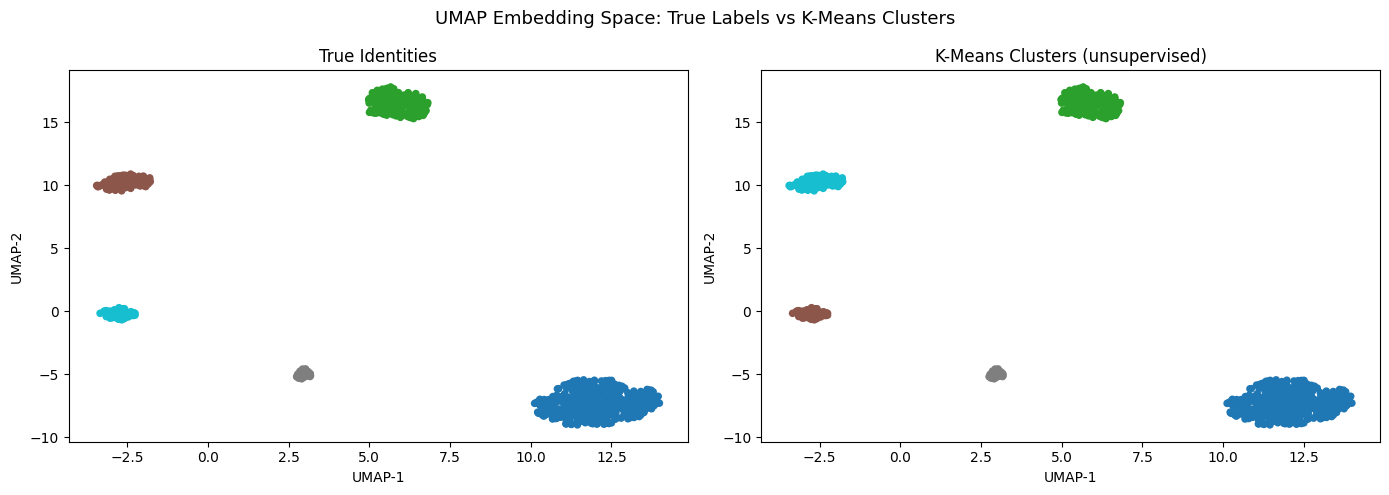

In [58]:
# ── Task 3: K-Means clustering on face embeddings ────────────────────────

# Step 1: Run K-Means with K=5 on ALL embeddings (Gallery + Query combined)
# TODO: create a KMeans object with n_clusters=5 and random_state=42
# Hint: from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=5, random_state=42)  # <- your code here

# TODO: fit K-Means on all embeddings and get cluster assignments
cluster_labels = kmeans.fit_predict(embeddings)  # <- your code here

print(f"K-Means found {len(np.unique(cluster_labels))} clusters")
print(f"Cluster sizes: {np.bincount(cluster_labels)}")

# Step 2: Evaluate clustering quality with Adjusted Rand Score (ARI)
# ARI = 1.0 means perfect match with true labels
# ARI = 0.0 means random (no better than chance)
# TODO: compute ARI between cluster_labels and true labels
# Hint: use adjusted_rand_score(labels, cluster_labels)
ari = adjusted_rand_score(labels, cluster_labels)  # <- your code here
print(f"\nAdjusted Rand Score (ARI): {ari:.3f}")
print("(1.0 = perfect clustering, 0.0 = random)")

# Step 3: Visualize clusters with UMAP
# Reduce embeddings to 2D, then color by CLUSTER (not by true label)
print("\nRunning UMAP...")
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
embeddings_2d = reducer.fit_transform(embeddings)

# TODO: create a scatter plot with 2 subplots side by side:
#   Left:  color by TRUE identity (y_gallery/y_query combined = labels)
#   Right: color by CLUSTER assignment (cluster_labels)
# This lets students visually compare what K-Means found vs the truth
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot — true labels
# <- your code here
scatter1 = axes[0].scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    c=labels,
    cmap='tab10',
    s=20
)

axes[0].set_title('True Identities', fontsize=12)
axes[0].set_xlabel('UMAP-1')
axes[0].set_ylabel('UMAP-2')

# Right plot — K-Means clusters
# <- your code here
scatter2 = axes[1].scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    c=cluster_labels,
    cmap='tab10',
    s=20
)

axes[1].set_title('K-Means Clusters (unsupervised)', fontsize=12)
axes[1].set_xlabel('UMAP-1')
axes[1].set_ylabel('UMAP-2')

plt.suptitle('UMAP Embedding Space: True Labels vs K-Means Clusters', fontsize=13)
plt.tight_layout()
plt.show()

**Task 3 — Analysis (write 3–5 sentences):**
- What ARI score did you get? Is the clustering good or poor?
- Looking at the UMAP side-by-side: do the K-Means clusters match the true identities?
- K-Means required you to set K=5 in advance. In a real-world scenario (e.g. Google Photos), you don't know how many people are in the dataset. How would you handle this?

*Answer*

The Adjusted Rand Index (ARI) is approximately 1.0, showing perfect clustering performance. This means that the K-Means algorithm has grouped the face embeddings very accurately, with each cluster corresponding to a unique identity. Looking at the UMAP output, the K-Means clusters closely match the true identities in terms of spatial grouping, even though the colors differ due to arbitrary cluster labeling.

In real-world scenarios where the number of identities is mostly likely unknown, we can use methods like the Elbow Method or Silhouette Score to estimate the optimal number of clusters or use a more flexible clustering algorithms like DBSCAN can automatically determine the number of clusters without requiring a predefined value of K.

---
### Task 4 — Effect of K in KNN Identification (15 pts)

In Session 3 we used K=5 for KNN identification. But is 5 the best value?

Your task: **test K values from 1 to 15**, plot accuracy vs K, and explain what you observe.

  K= 1  →  Accuracy: 100.00%
  K= 2  →  Accuracy: 100.00%
  K= 3  →  Accuracy: 100.00%
  K= 4  →  Accuracy: 100.00%
  K= 5  →  Accuracy: 100.00%
  K= 6  →  Accuracy: 100.00%
  K= 7  →  Accuracy: 100.00%
  K= 8  →  Accuracy: 100.00%
  K= 9  →  Accuracy: 100.00%
  K=10  →  Accuracy: 100.00%
  K=11  →  Accuracy: 100.00%
  K=12  →  Accuracy: 100.00%
  K=13  →  Accuracy: 100.00%
  K=14  →  Accuracy: 100.00%
  K=15  →  Accuracy: 100.00%

Best K: 1  →  Accuracy: 100.00%


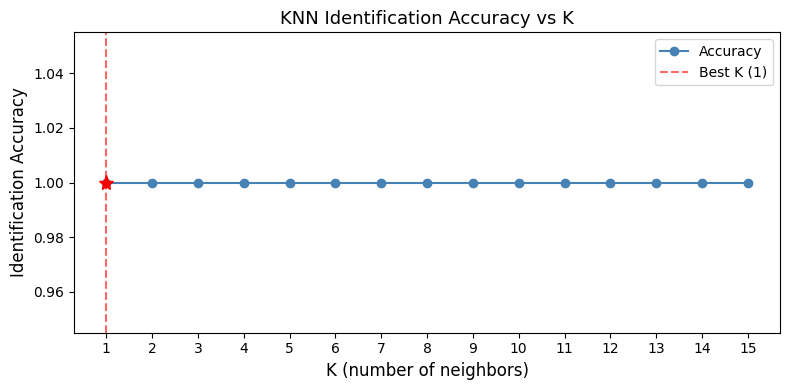

In [59]:
# ── Task 4: Effect of K on identification accuracy ────────────────────────

# Step 1: Test K = 1, 2, 3, ..., 15
k_values = list(range(1, 16))
k_accuracies = []

# TODO: for each K, train a KNN on the Gallery and evaluate on the Query
# Store the accuracy for each K in k_accuracies
for k in k_values:
    # <- create KNeighborsClassifier with n_neighbors=k, metric='cosine'
    knn_k = KNeighborsClassifier(n_neighbors=k, metric='cosine')
    # <- fit on Gallery
    knn_k.fit(X_gallery, y_gallery)

    # <- predict on Query
    y_pred_k = knn_k.predict(X_query)

    acc = accuracy_score(y_query, y_pred_k)    # <- compute accuracy
    k_accuracies.append(acc)
    print(f"  K={k:2d}  →  Accuracy: {acc:.2%}")

# Step 2: Find the best K
# TODO: find the K with the highest accuracy
best_k   = k_values[np.argmax(k_accuracies)]  # <- your code here
best_acc = k_accuracies[np.argmax(k_accuracies)]  # <- your code here
print(f"\nBest K: {best_k}  →  Accuracy: {best_acc:.2%}")

# Step 3: Plot accuracy vs K
# TODO: line plot with K on x-axis, accuracy on y-axis
# Mark the best K with a vertical dashed line or a star marker
fig, ax = plt.subplots(figsize=(8, 4))
# <- your plotting code here
ax.plot(k_values, k_accuracies, marker='o', color='steelblue', label='Accuracy')
ax.axvline(x=best_k, linestyle='--', color='red', alpha=0.6, label=f'Best K ({best_k})')
ax.plot(best_k, best_acc, marker='*', markersize=11, color='red')

ax.legend()

ax.set_xlabel('K (number of neighbors)', fontsize=12)
ax.set_ylabel('Identification Accuracy', fontsize=12)
ax.set_title('KNN Identification Accuracy vs K', fontsize=13)
ax.set_xticks(k_values)
plt.tight_layout()
plt.show()

**Task 4 — Analysis (write 3–4 sentences):**
- What is the best K you found?
- What happens to accuracy when K is very small (K=1)? When K is very large (K=15)?
- Why does K=1 sometimes perform well but can also be unreliable? (Hint: think about noisy embeddings)

*Answer*

The best value of K found is `K = 1`, although all values of K from 1 to 15 achieve 100% accuracy, indicating that the embeddings are very well separated. When K is very small (K=1), the model relies on the single nearest neighbor, making it highly sensitive to individual samples. When K is large (K=15), the model considers more neighbors, which can make it more stable but but potentially smoothing over class boundaries if the data is less clearly separated.

Although K=1 performs perfectly in this case, it can be unreliable in real-world scenarios because it is sensitive to noisy or misrepresented embeddings, where a single incorrect neighbor can lead to misclassification.

---
# Part 3 — Extension Project
### 20 points

Choose **ONE** of the two extension options below. Both are worth 20 points.

---
**Option A — Add a 6th Person**

The LFW dataset contains more people. Add a **6th person** of your choice to the pipeline and re-run verification, identification, and clustering. Analyze how adding a new person affects performance.

---
**Option B — Build a Face Search Function**

Implement a `find_most_similar(query_embedding, gallery_embeddings, gallery_labels, top_n=3)` function that, given a query face, returns the **top-N most similar faces** from the Gallery with their distances and identities. Visualize the results for 5 different query faces.

---

**Which option did you choose?** *(B)*

**Option B: Build a Face Search Function**


The goal is to take a query face embedding, compare it with all gallery embeddings, compute the similarity distance, and return the top-N most similar faces.

In [60]:
# ── Part 3: Extension Project ─────────────────────────────────────────────
# Implement your chosen option here.
# Add as many code cells as you need.

# YOUR CODE HERE


# using names instead of numeric labels
label_to_name = {i: name for i, name in enumerate(SELECTED_PEOPLE)}

# function to find the 'top-N' most similar gallery faces to a query embedding and
# returns top_indices, top_labels, top_distances of top-N most similar gallery images

# parameters used in the function
# query_embedding: 1D numpy array for the query face embedding
# gallery_embeddings: 2D numpy array of gallery embeddings
# gallery_labels: 1D numpy array of gallery identity labels
# top_n: number of most similar results to return
def find_most_similar(query_embedding, gallery_embeddings, gallery_labels, top_n=3):
    distances = np.array([cosine(query_embedding, emb) for emb in gallery_embeddings])

    sorted_indices = np.argsort(distances)
    top_indices = sorted_indices[:top_n]
    top_labels = gallery_labels[top_indices]
    top_distances = distances[top_indices]

    return top_indices, top_labels, top_distances

**Visualizing identities and distances clearly**
To show the results properly we need: query image, gallery images and titles showing identity + distance.

In [61]:
# function to display one query image and its top-N most similar gallery matches
def print_top_matches(query_idx, X_query, X_gallery, y_gallery, label_to_name, top_n=3):
    query_embedding = X_query[query_idx]
    top_indices, top_labels, top_distances = find_most_similar(
        query_embedding, X_gallery, y_gallery, top_n=top_n
    )

    print(f"\nQuery index: {query_idx}")
    for rank, (idx, label, dist) in enumerate(zip(top_indices, top_labels, top_distances), start=1):
        print(f"Rank {rank}: Gallery index {idx}, Identity = {label_to_name[label]}, Distance = {dist:.4f}")

To make the visualization more appealing we are going to display the images (both query and gallery images) with labels and distance.


Query index: 3
Rank 1: Gallery index 358, Identity = George W Bush, Distance = 0.0482
Rank 2: Gallery index 126, Identity = George W Bush, Distance = 0.0525
Rank 3: Gallery index 645, Identity = George W Bush, Distance = 0.0712


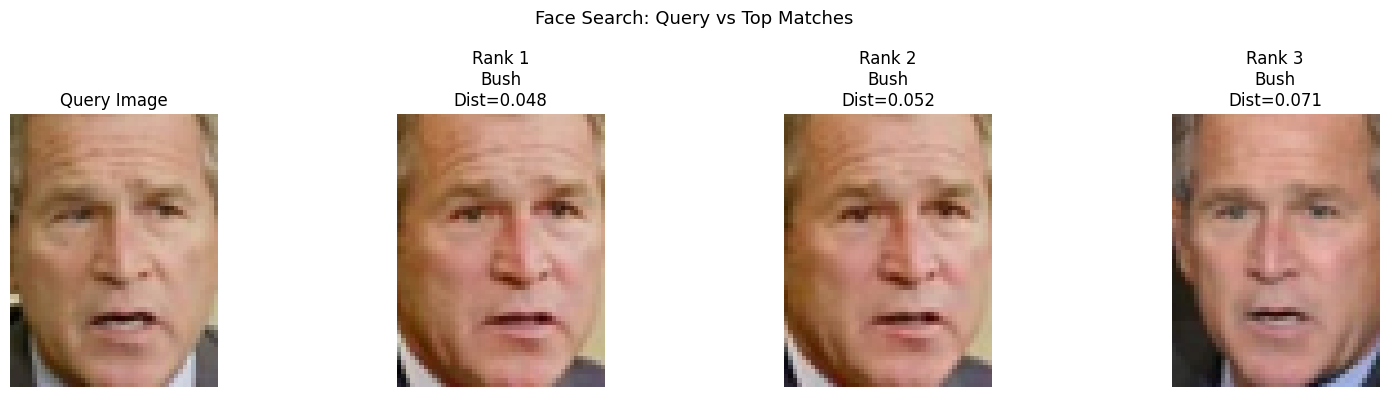


Query index: 23
Rank 1: Gallery index 767, Identity = Colin Powell, Distance = 0.0610
Rank 2: Gallery index 501, Identity = Colin Powell, Distance = 0.0621
Rank 3: Gallery index 561, Identity = Colin Powell, Distance = 0.0705


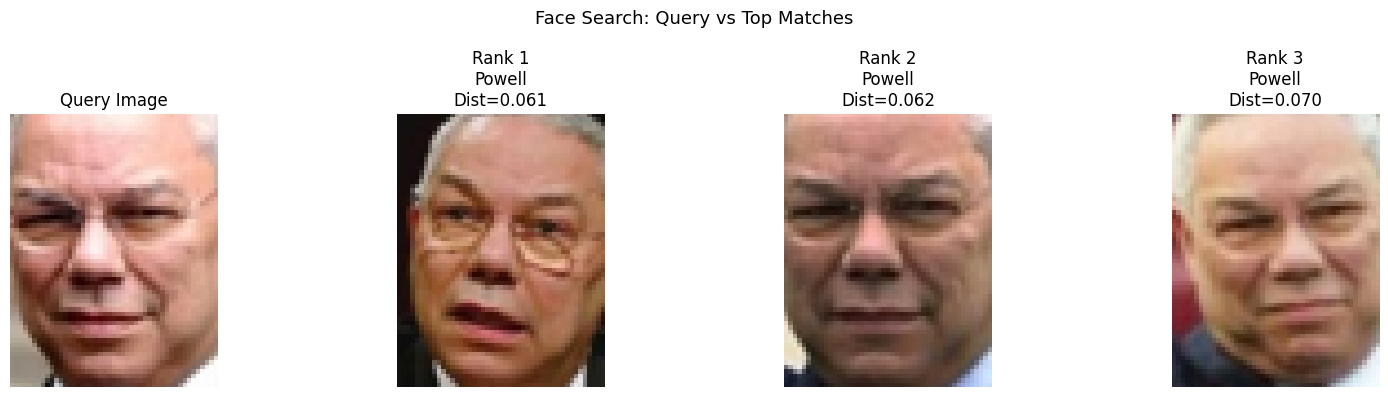


Query index: 12
Rank 1: Gallery index 493, Identity = Tony Blair, Distance = 0.1351
Rank 2: Gallery index 594, Identity = Tony Blair, Distance = 0.1557
Rank 3: Gallery index 290, Identity = Tony Blair, Distance = 0.1576


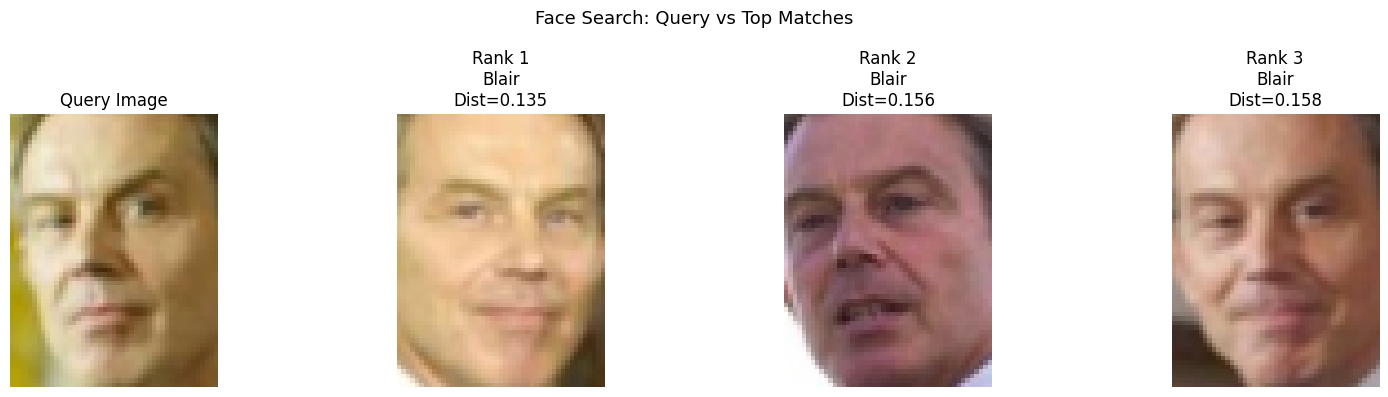


Query index: 5
Rank 1: Gallery index 438, Identity = Vladimir Putin, Distance = 0.0776
Rank 2: Gallery index 540, Identity = Vladimir Putin, Distance = 0.0851
Rank 3: Gallery index 110, Identity = Vladimir Putin, Distance = 0.1020


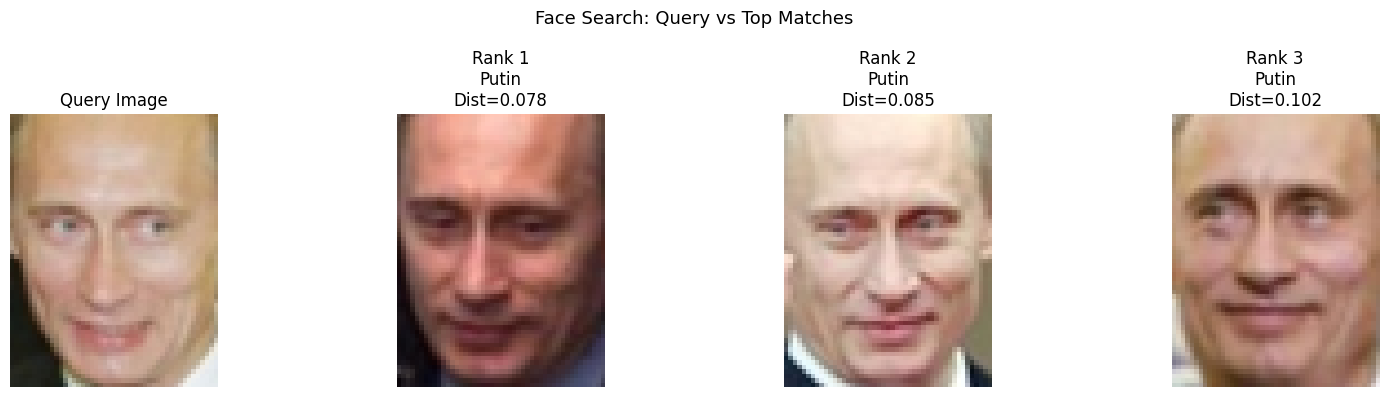


Query index: 0
Rank 1: Gallery index 730, Identity = Ariel Sharon, Distance = 0.0636
Rank 2: Gallery index 742, Identity = Ariel Sharon, Distance = 0.1006
Rank 3: Gallery index 605, Identity = Ariel Sharon, Distance = 0.1071


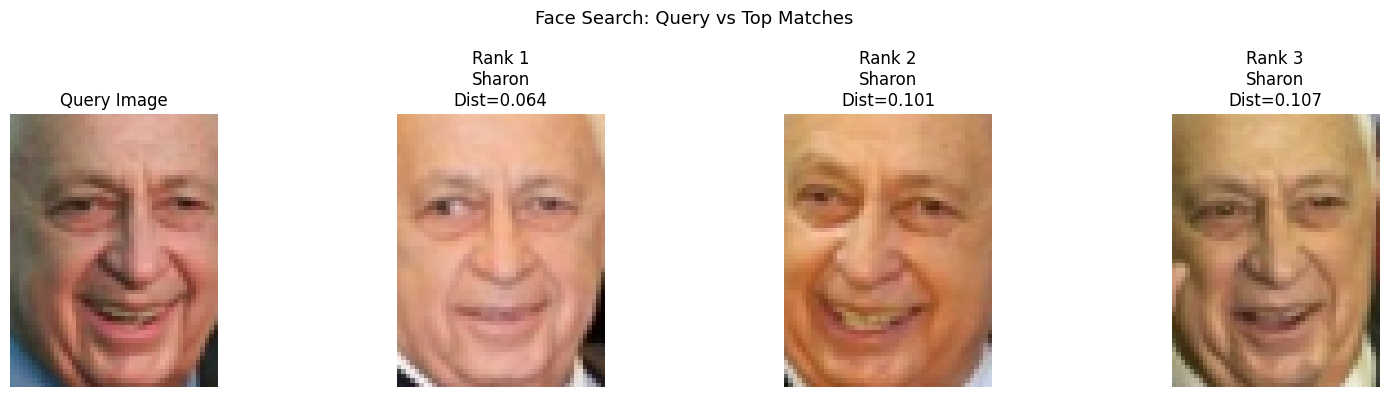

In [62]:
# function to show the top matches images
def show_top_matches(query_idx, X_query, X_gallery, y_gallery, query_images, gallery_images,
                     label_to_name, top_n=3):
    query_embedding = X_query[query_idx]
    top_indices, top_labels, top_distances = find_most_similar(
        query_embedding, X_gallery, y_gallery, top_n=top_n
    )

    fig, axes = plt.subplots(1, top_n + 1, figsize=(4 * (top_n + 1), 4))

    axes[0].imshow(query_images[query_idx], cmap='gray')
    axes[0].set_title("Query Image")
    axes[0].axis('off')

    for i, (idx, label, dist) in enumerate(zip(top_indices, top_labels, top_distances), start=1):
        axes[i].imshow(gallery_images[idx], cmap='gray')
        axes[i].set_title(f"Rank {i}\n{label_to_name[label].split()[-1]}\nDist={dist:.3f}")
        axes[i].axis('off')

    plt.suptitle("Face Search: Query vs Top Matches", fontsize=13)
    plt.tight_layout()
    plt.show()

# Recreate the same split for images only
_, _, _, _, gallery_images, query_images = train_test_split(
    embeddings, labels, images,
    test_size=0.2,
    random_state=42,
    stratify=labels
)
# using manual query_index
# query_indices = [0, 5, 10, 15, 20]

# To make it more efficient, I commented the manaul query indices and
# use y_query (labels) to find one query image per person automatically
query_indices = []
for person_id in range(len(SELECTED_PEOPLE)):
    idx = np.where(y_query == person_id)[0][0]  # pick first occurrence
    query_indices.append(idx)


for q_idx in query_indices:
    print_top_matches(q_idx, X_query, X_gallery, y_gallery, label_to_name, top_n=3)
    show_top_matches(
        q_idx, X_query, X_gallery, y_gallery,
        query_images, gallery_images, label_to_name, top_n=3
    )

**Part 3 — Description and Analysis:**

Describe what you implemented and what you observed. Write at least 5 sentences covering:
- What you built and how it works
- What results you got
- What surprised you or what was harder than expected

*Answer*

I extend the project by working on the Option B: Build a Face Search Function. We implemented a face search function to retrieve the top-N most similar faces from the Gallery for a given query embedding. The system computes cosine distances between the query embedding and all gallery embeddings, then ranks the results from smallest to largest distance. Lower cosine distance indicates higher similarity, meaning the top-ranked results should ideally belong to the same identity as the query image.

The results show that the function performs very well, as the top-3 matches for each query consistently belong to the correct identity. For example, queries of Colin Powell, Tony Blair, Ariel Sharon, Putin and George W Bush all returned the correct person as the top matches, with low cosine distances around 0.04 – 0.13, indicating strong similarity in the embedding space.

One notable observation is that even with variations in lighting, facial expression, and pose, the model still retrieves correct matches for the person. This also confirms the advantage of FaceNet embeddings to effectively capture identity-specific features.

One challenge was correctly interpreting the similarity scores and ensuring that the ranking was based on ascending cosine distance, since smaller values indicate higher similarity. Additionally, selecting appropriate query samples required careful attention, as some indices like 10 and 15 corresponded to images of the same person (Bush), leading to repetitive results. We can decide to manually adjust the query indices to include images from different individuals but it is less efficient. To address this, we use query samples were automatically selected based on their labels ensure that each chosen index represented a different person.

---
# Part 4 — Reflection
### 5 points

Answer the following questions in 4–6 sentences total. Be honest — there are no wrong answers here.

**1. What was the most difficult part of this assignment for you?**

*The code lab is well detailed with the comments and hints, so it is difficult to pin-point a difficult part from the assignment. The only part that seems difficult and not really difficult is when we were asked to extend the program, so deciding on the option to pick without the "TODO GUIDE and HINT" like in previous Task 1-3 make it kindof a difficult task but it also help improve my coding and implementation skill.*

---

**2. What concept from Sessions 1–3 do you feel you now understand better after doing this assignment?**

*I missed the onsite class for session 3, but doing the assignment and answering the Theory section of the assignment makes me go back and study the lecture slide once more. So, for me the assignment makes me understand all what we talked about from session 1-3 far better and see how what we talk about in class works in practice.*

---

**3. If you were building a real face recognition system (e.g. for a university entrance gate), what would you do differently compared to what we built in this notebook?**

*I'm a UI/UX guy and like asthetics which was why I extend the assignment to display the people image and not just assuming students know who is who. So, I think if I want to develop a real face recognition system, the user expereince can be improved. Also, in extending the program, we might be task to allow user to upload a new query image of same person different from what we have in the Gallery to test the model.*

*Overall the assignment is well-detailed, procedural and makes students go back to lecture slides. This a very good way to lecture and I wish all lab session in other courses can be like this. Thank you Professor.*

---
## Submission Checklist

Before submitting, make sure:

- [ ] Your name and student ID are filled in at the top
- [ ] All code cells are **run** and outputs are visible
- [ ] All theory questions (Part 1) are answered in the markdown cells
- [ ] All 4 coding tasks (Part 2) are completed with plots showing
- [ ] Part 3 extension is implemented and described
- [ ] Part 4 reflection is filled in
- [ ] You have exported the notebook as **PDF** (File → Print → Save as PDF in Colab)
- [ ] You submit **both** the `.ipynb` file and the `.pdf` on Teams

---

### References
- Huang et al. (2007). *Labeled Faces in the Wild*. UMass Amherst.
- Schroff et al. (2015). *FaceNet: A Unified Embedding for Face Recognition and Clustering*. CVPR.
- Session 1, 2, 3 slides and notebooks — Arezoo Ghodsifard, UPEC.